# Notebook 08: Q-Learning — Off-Policy TD Control

**Series:** Reinforcement Learning Basics (8/20)

---

## 1. Q-Learning Update

$$\boxed{Q(S_t, A_t) \leftarrow Q(S_t, A_t) + \alpha \Big[ R_{t+1} + \gamma \max_a Q(S_{t+1}, a) - Q(S_t, A_t) \Big]}$$

**Off-Policy:** Uses $\max_a Q(S_{t+1}, a)$ regardless of what action is actually taken. Learns $Q^*$ while following any exploration policy.

## 2. Why Off-Policy is Powerful

- Learn from **demonstrations** (watching an expert)
- **Experience replay** (reuse old data)
- Learn about **multiple policies** simultaneously
- Learn **optimal** policy while exploring

## 3. Maximization Bias

$$\mathbb{E}[\max_a Q(s,a)] \geq \max_a \mathbb{E}[Q(s,a)]$$

Q-Learning can **overestimate** values because it uses the max operator on noisy estimates.

## 4. Double Q-Learning

Use **two** Q-tables to decouple selection and evaluation:

1. With probability 0.5, update $Q_1$:
$$Q_1(S_t, A_t) \leftarrow Q_1(S_t, A_t) + \alpha[R_{t+1} + \gamma Q_2(S_{t+1}, \arg\max_a Q_1(S_{t+1}, a)) - Q_1(S_t, A_t)]$$

2. Otherwise, update $Q_2$ analogously (swap roles).

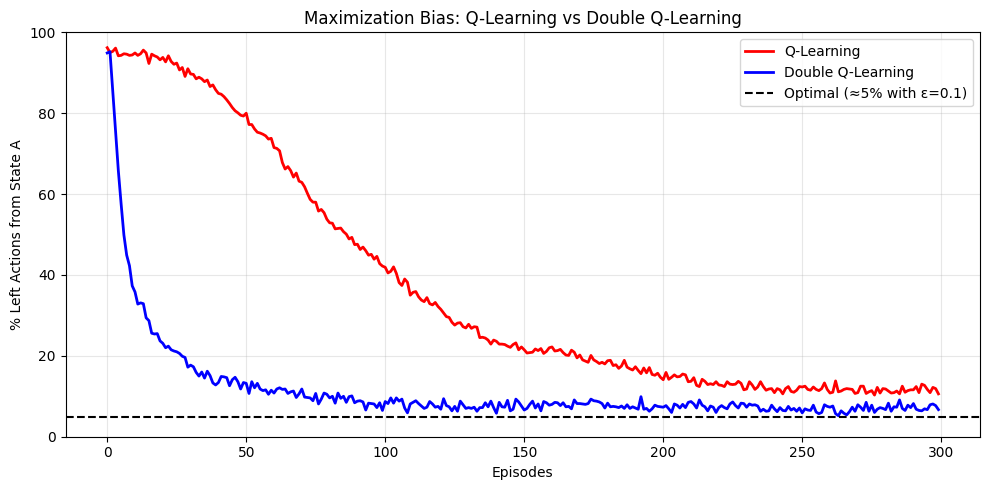

Q-Learning overestimates 'left' because max over noisy Q-values is biased upward.
Double Q-Learning uses separate tables to break this correlation.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================
# Maximization Bias Example
# ============================================
# State A: left or right
# Left -> State B, reward 0
# From B: many actions, each gives N(-0.1, 1) reward, then terminal
# Right -> terminal, reward 0
# Optimal: go right (expected reward 0 > -0.1)
# But Q-learning initially overestimates left due to max bias

def run_experiment(n_episodes=300, n_runs=1000, double=False):
    left_counts = np.zeros(n_episodes)

    for run in range(n_runs):
        Q1_A = np.array([0.0, 0.0])  # [left, right]
        Q1_B = np.zeros(10)  # 10 actions from state B
        if double:
            Q2_A = np.array([0.0, 0.0])
            Q2_B = np.zeros(10)

        alpha = 0.1
        epsilon = 0.1

        for ep in range(n_episodes):
            # State A: choose action
            if np.random.random() < epsilon:
                action_A = np.random.randint(2)
            else:
                if double:
                    action_A = np.argmax(Q1_A + Q2_A)
                else:
                    action_A = np.argmax(Q1_A)

            if action_A == 0:  # left
                left_counts[ep] += 1

            if action_A == 1:  # right -> terminal, reward 0
                if double:
                    if np.random.random() < 0.5:
                        Q1_A[1] += alpha * (0 - Q1_A[1])
                    else:
                        Q2_A[1] += alpha * (0 - Q2_A[1])
                else:
                    Q1_A[1] += alpha * (0 - Q1_A[1])
            else:  # left -> state B
                # Choose action in B
                if np.random.random() < epsilon:
                    action_B = np.random.randint(10)
                else:
                    if double:
                        action_B = np.argmax(Q1_B + Q2_B)
                    else:
                        action_B = np.argmax(Q1_B)

                reward_B = np.random.normal(-0.1, 1.0)

                if double:
                    if np.random.random() < 0.5:
                        Q1_B[action_B] += alpha * (reward_B - Q1_B[action_B])
                        best_B = np.argmax(Q1_B)
                        Q1_A[0] += alpha * (0 + Q2_B[best_B] - Q1_A[0])
                    else:
                        Q2_B[action_B] += alpha * (reward_B - Q2_B[action_B])
                        best_B = np.argmax(Q2_B)
                        Q2_A[0] += alpha * (0 + Q1_B[best_B] - Q2_A[0])
                else:
                    Q1_B[action_B] += alpha * (reward_B - Q1_B[action_B])
                    Q1_A[0] += alpha * (0 + np.max(Q1_B) - Q1_A[0])

    return left_counts / n_runs * 100  # percentage

pct_left_ql = run_experiment(double=False)
pct_left_dql = run_experiment(double=True)

plt.figure(figsize=(10, 5))
plt.plot(pct_left_ql, label='Q-Learning', linewidth=2, color='red')
plt.plot(pct_left_dql, label='Double Q-Learning', linewidth=2, color='blue')
plt.axhline(5, color='black', linestyle='--', label='Optimal (≈5% with ε=0.1)')
plt.xlabel('Episodes')
plt.ylabel('% Left Actions from State A')
plt.title('Maximization Bias: Q-Learning vs Double Q-Learning')
plt.legend()
plt.ylim(0, 100)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("Q-Learning overestimates 'left' because max over noisy Q-values is biased upward.")
print("Double Q-Learning uses separate tables to break this correlation.")

## Summary

| Algorithm | Update | Key Property |
|-----------|--------|-------------|
| **Q-Learning** | $Q(s,a) \leftarrow Q(s,a) + \alpha[R + \gamma \max_{a'} Q(s',a') - Q(s,a)]$ | Off-policy, learns $Q^*$ |
| **Double Q-Learning** | Decouple selection ($Q_1$) and evaluation ($Q_2$) | Reduces maximization bias |

**Next:** Notebook 09 — N-Step Bootstrapping